**MOVIE RATING PREDICTION**

**AUTHOR: VIKRAM SINGH KUSHWAHA**

**DOMAIN: DATA SCIENCE**

**BATCH: FEBRURARY 20**



In [77]:
!pip install numpy pandas seaborn matplotlib
!pip install -U nbformat

In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

In [79]:
df = pd.read_csv("IMDb Movies India.csv", encoding='latin-1')
df

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali
...,...,...,...,...,...,...,...,...,...,...
15504,Zulm Ko Jala Doonga,(1988),NaN,Action,4.6,11,Mahendra Shah,Naseeruddin Shah,Sumeet Saigal,Suparna Anand
15505,Zulmi,(1999),129 min,"Action, Drama",4.5,655,Kuku Kohli,Akshay Kumar,Twinkle Khanna,Aruna Irani
15506,Zulmi Raj,(2005),NaN,Action,NaN,NaN,Kiran Thej,Sangeeta Tiwari,NaN,NaN
15507,Zulmi Shikari,(1988),NaN,Action,NaN,NaN,NaN,NaN,NaN,NaN


In [80]:
df.shape

(15509, 10)

Data Cleaning

In [81]:
df.isnull().sum()

Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64

In [82]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  str    
 1   Year      14981 non-null  str    
 2   Duration  7240 non-null   str    
 3   Genre     13632 non-null  str    
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   str    
 6   Director  14984 non-null  str    
 7   Actor 1   13892 non-null  str    
 8   Actor 2   13125 non-null  str    
 9   Actor 3   12365 non-null  str    
dtypes: float64(1), str(9)
memory usage: 1.2 MB


In [83]:
df.duplicated().sum()

np.int64(6)

In [84]:
df.dropna(inplace=True)

In [85]:
df.shape

(5659, 10)

In [86]:
df.isnull().sum()

Name        0
Year        0
Duration    0
Genre       0
Rating      0
Votes       0
Director    0
Actor 1     0
Actor 2     0
Actor 3     0
dtype: int64

In [87]:
df.columns

Index(['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director',
       'Actor 1', 'Actor 2', 'Actor 3'],
      dtype='str')

**Data Pre-processing**


Data have to be processed to make more easier to derive insights from it and pre-processed will be more suitable while fitting the data into an algorithm.

In this project we have processed the data by column wise based on the
requirement


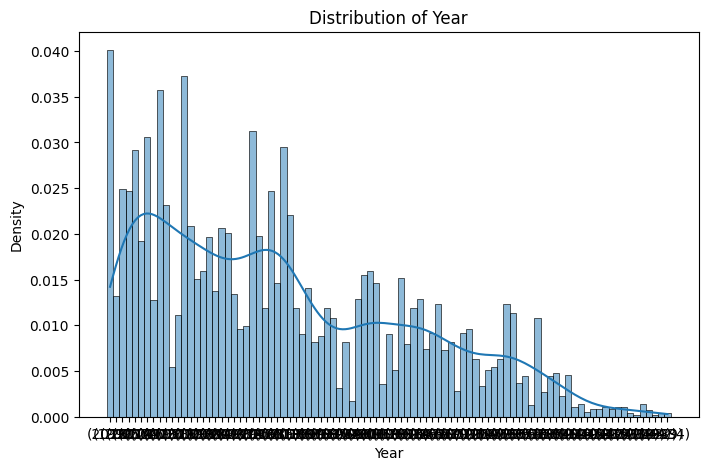

In [89]:
#Here we have created a histogram over the years in the data

plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='Year',
    bins=30,
    stat='density',   # equivalent to histnorm='probability density'
    kde=True          # optional: adds smooth curve
)

plt.title("Distribution of Year")
plt.xlabel("Year")
plt.ylabel("Density")

plt.show()

In [90]:
# Replacing the brackets from year column
df['Year'] = df['Year'].str.replace(r'[()]', '', regex=True).astype(int)

In [91]:
# Remove the min word from 'Duration' column and convert all values to numeric
df['Duration'] = pd.to_numeric(df['Duration'].str.replace(' min', ''))

In [92]:
# Splitting the genre by, to keep only unique genres and replacing the null values with mode
df['Genre'] = df['Genre'].str.split(', ')
df = df.explode('Genre')
df['Genre'].fillna(df['Genre'].mode()[0], inplace=True)

1          Drama
3         Comedy
3        Romance
5         Comedy
5          Drama
          ...   
15503      Drama
15505     Action
15505      Drama
15508     Action
15508      Drama
Name: Genre, Length: 11979, dtype: str

In [93]:
# Convert 'Votes' to numeric and replace the , to keep only numerical part
df['Votes'] = pd.to_numeric(df['Votes'].str.replace(',', ''))

In [94]:
# Checking the dataset is there any null values present and data types of the features present
df.info()

<class 'pandas.DataFrame'>
Index: 11979 entries, 1 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      11979 non-null  str    
 1   Year      11979 non-null  int64  
 2   Duration  11979 non-null  int64  
 3   Genre     11979 non-null  str    
 4   Rating    11979 non-null  float64
 5   Votes     11979 non-null  int64  
 6   Director  11979 non-null  str    
 7   Actor 1   11979 non-null  str    
 8   Actor 2   11979 non-null  str    
 9   Actor 3   11979 non-null  str    
dtypes: float64(1), int64(3), str(6)
memory usage: 1.0 MB


**Data Visualization**

Visualization part is done to show the realtionships between the features present in the dataset.

In this project, we have used multiple charts to see the realtions within components of data which involves in the result.

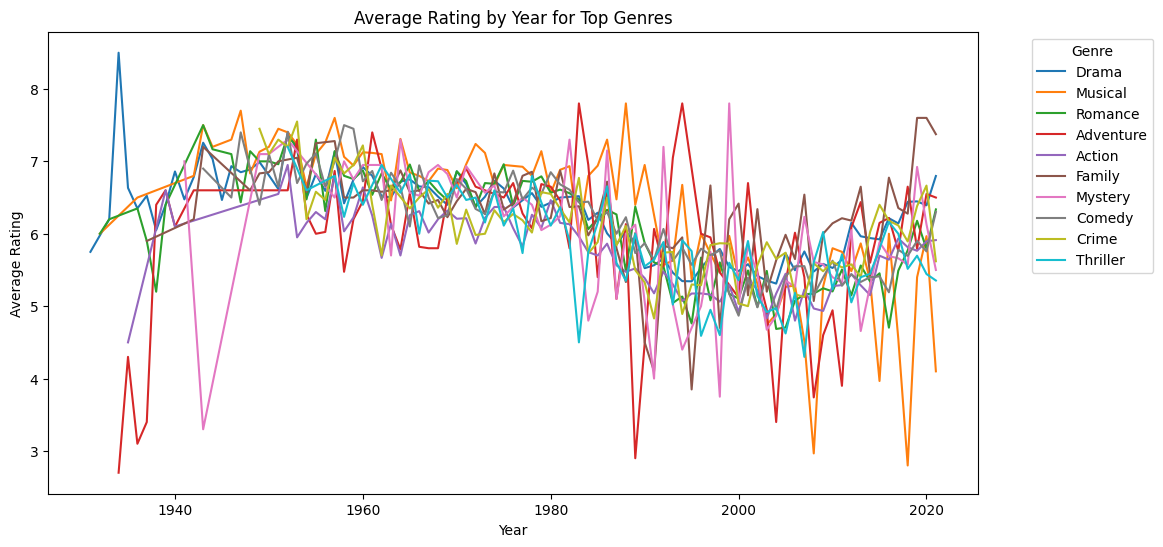

In [96]:
# Group data by Year and calculate the average rating
avg_rating_by_year = df.groupby(['Year', 'Genre'])['Rating'].mean().reset_index()

# Get top 10 genres
top_genres = df['Genre'].value_counts().head(10).index

# Filter only top genres
avg_rating_by_year = avg_rating_by_year[avg_rating_by_year['Genre'].isin(top_genres)]

# Plot
plt.figure(figsize=(12,6))

sns.lineplot(
    data=avg_rating_by_year,
    x='Year',
    y='Rating',
    hue='Genre'
)

plt.title('Average Rating by Year for Top Genres')
plt.xlabel('Year')
plt.ylabel('Average Rating')
plt.legend(title='Genre', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

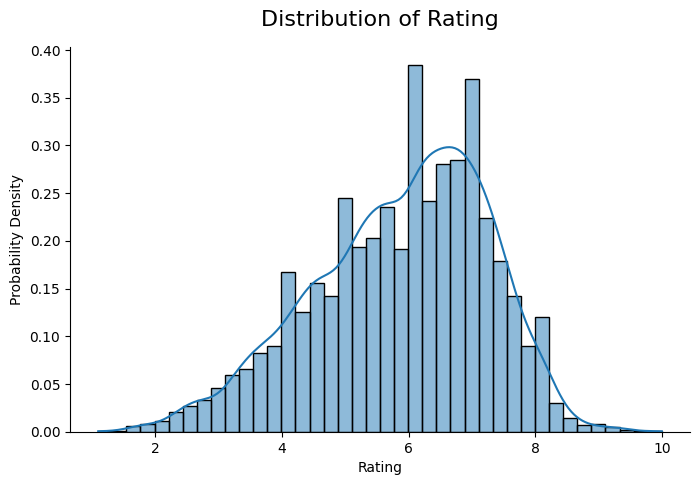

In [98]:
#This histogram shows the distribution of ratings and its probable density

plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='Rating',
    bins=40,
    stat='density',   # equivalent to probability density
    kde=True          # smooth curve (optional but nice)
)

plt.title('Distribution of Rating', fontsize=16, pad=15)
plt.xlabel('Rating')
plt.ylabel('Probability Density')

# Remove grid (like your Plotly style)
sns.despine()

plt.show()

**Feature Engineering**

In [99]:
# Importing essential libraries for model building

from sklearn.model_selection import train_test_split, cross_val_score

from sklearn.linear_model import LinearRegression

from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error, r2_score

In [100]:
# Dropping Name column because it doesn't impact the outcome
df.drop('Name', axis = 1, inplace = True)

In [101]:
# Grouping the columns with their average rating and then creating a new feature

genre_mean_rating = df.groupby('Genre')['Rating'].transform('mean')
df['Genre_mean_rating'] = genre_mean_rating

director_mean_rating = df.groupby('Director')['Rating'].transform('mean')
df['Director_encoded'] = director_mean_rating

actor1_mean_rating = df.groupby('Actor 1')['Rating'].transform('mean')
df['Actor1_encoded'] = actor1_mean_rating

actor2_mean_rating = df.groupby('Actor 2')['Rating'].transform('mean')
df['Actor2_encoded'] = actor2_mean_rating

actor3_mean_rating = df.groupby('Actor 3')['Rating'].transform('mean')
df['Actor3_encoded'] = actor3_mean_rating

In [102]:
# Keeping the predictor and target variable

X = df[[ 'Year', 'Votes', 'Duration', 'Genre_mean_rating','Director_encoded','Actor1_encoded', 'Actor2_encoded', 'Actor3_encoded']]
y = df['Rating']

In [103]:
# Splitting the dataset into training and testing parts

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

**Model Building**

In [104]:
# Building machine learning model and training them
Model = LinearRegression()
Model.fit(X_train,y_train)
Model_pred = Model.predict(X_test)

In [105]:
# Evaluating the performance of model with evaluation metrics

print('The performance evaluation of Logistic Regression is below: ', '\n')
print('Mean squared error: ',mean_squared_error(y_test, Model_pred))
print('Mean absolute error: ',mean_absolute_error(y_test, Model_pred))
print('R2 score: ',r2_score(y_test, Model_pred))

The performance evaluation of Logistic Regression is below:  

Mean squared error:  0.4465441653985702
Mean absolute error:  0.49219025407656386
R2 score:  0.7641133663863862


**Model Testing**

In [106]:
X.head(5)

,Year,Votes,Duration,Genre_mean_rating,Director_encoded,Actor1_encoded,Actor2_encoded,Actor3_encoded
1,2019,8,109,6.056744,7.000000,6.850000,7.00,7.00
3,2019,35,110,5.751042,4.400000,5.250000,4.40,4.46
3,2019,35,110,5.811087,4.400000,5.250000,4.40,4.46
5,1997,827,147,5.751042,5.335135,4.793617,5.73,5.93
5,1997,827,147,6.056744,5.335135,4.793617,5.73,5.93


In [107]:
y.head(5)

1    7.0
3    4.4
3    4.4
5    4.7
5    4.7
Name: Rating, dtype: float64

In [108]:
# For testing, We create a new dataframe with values close to the any of our existing data to evaluate.

data = {'Year': [2019], 'Votes': [36], 'Duration': [111], 'Genre_mean_rating': [5.8], 'Director_encoded': [4.5], 'Actor1_encoded': [5.3], 'Actor2_encoded': [4.5], 'Actor3_encoded': [4.5]}
trail = pd.DataFrame(data)

In [109]:
# Predict the movie rating by entered data
rating_predicted = Model.predict(trail)

# Display the predicted result from the Model
print("Predicted Rating:", rating_predicted[0])

Predicted Rating: 4.207458962134328
